#**1.Data Cleaning**

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing imports
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_auc_score, roc_curve

# Model imports
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import ComplementNB




In [2]:
# Load dataset
df = pd.read_csv("fake_job_postings.csv")

# Display basic information
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

df.head()

Dataset Shape: (17880, 18)

Data Types:
job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# **2. Check Missing Values & Duplicates**

In [3]:
#check missing values and duplicates
print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))


Missing Values:
salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
title                      0
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
fraudulent                 0
dtype: int64


In [4]:
# Define target
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(list(numerical_columns))

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(list(categorical_columns))

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

print("Text columns:")
print(text_columns)

Numerical columns:
['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
Categorical columns:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
Text columns:
['title', 'company_profile', 'description', 'requirements', 'benefits']


In [5]:
# Handle missing values

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

for col in text_columns:
    df[col] = df[col].fillna("Unknown")

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
job_id                 0
title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64


In [6]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Remove duplicates if any exist
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (17880, 18)


**text cleaning**

In [7]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [8]:
for col in text_columns:
    df[col] = df[col].apply(clean_text)
# Show text columns after cleaning
df[text_columns].head()

,title,company_profile,description,requirements,benefits
0,marketing intern,were food52 and weve created a groundbreaking ...,food52 a fastgrowing james beard awardwinning ...,experience with content management systems a m...,unknown
1,customer service cloud video production,90 seconds the worlds cloud video production s...,organised focused vibrant awesomedo you have a...,what we expect from youyour key responsibility...,what you will get from usthrough being part of...
2,commissioning machinery assistant cma,valor services provides workforce solutions th...,our client located in houston is actively seek...,implement precommissioning and commissioning p...,unknown
3,account executive washington dc,our passion for improving quality of life thro...,the company esri – environmental systems resea...,education bachelor’s or master’s in gis busine...,our culture is anything but corporate—we have ...
4,bill review manager,spotsource solutions llc is a global human cap...,job title itemization review managerlocation f...,qualificationsrn license in the state of texas...,full benefits offered


In [9]:
# Check Class Distribution

print(df["fraudulent"].value_counts())

fraudulent
0    17014
1      866
Name: count, dtype: int64


# **4. Feature Engineering**

In [10]:
columns = [
    "department",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "salary_range",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "location"
]

df["missing_fields_count"] = (
    df[columns].astype(str).apply(
        lambda col: col.str.lower() == "unknown"
    )
).sum(axis=1)



A single feature, `missing_fields_count`, was created to measure the completeness of each job posting. It represents the total number of missing fields across the selected textual and categorical attributes.

This feature does not directly determine whether a job posting is fraudulent. Instead, it provides the machine learning model with additional information that can be used to learn whether the completeness of a job posting is associated with fraudulent behavior.

In [11]:
#Information availability
df["has_salary"] = (df["salary_range"] != "Unknown").astype(int)

df["has_description"] = (df["description"] != "unknown").astype(int)

df["has_company_profile"] = (
    df["company_profile"] != "unknown"
).astype(int)

df["has_requirements"] = (
    df["requirements"] != "unknown"
).astype(int)

df["has_benefits"] = (
    df["benefits"] != "unknown"
).astype(int)

df["has_location"] = (
    df["location"] != "Unknown"
).astype(int)

df["title_len"] = df["title"].apply(len)

df["description_len"] = df["description"].apply(len)



### Information Availability Features

Binary features were created to indicate whether important job posting information is available.

These features include `has_salary`, `has_description`, `has_company_profile`, `has_requirements`, `has_benefits`, and `has_location`.

Each feature takes a value of `1` when the corresponding information is available and `0` when it is missing.

This allows the model to distinguish between the presence and absence of specific job posting information instead of relying only on the overall number of missing fields.


In [12]:
df["job_context"] = (
    df["title"].astype(str)
    + " "
    + df["industry"].apply(clean_text)
    + " "
    + df["function"].apply(clean_text)
)

### Job Context Feature

A combined textual feature called `job_context` was created by combining the job title, industry, and function.

This feature provides additional context about the type and domain of the job. It will be included as part of the text representation and transformed using TF-IDF.


# EDA


In [13]:
# Overview of the cleaned dataset and target distribution
print(f"Dataset shape: {df.shape}")
print(f"Fraudulent postings: {df['fraudulent'].sum():,}")
print(f"Real postings: {(df['fraudulent'] == 0).sum():,}")
print(f"Fraud rate: {df['fraudulent'].mean():.1%}")

Dataset shape: (17880, 28)
Fraudulent postings: 866
Real postings: 17,014
Fraud rate: 4.8%


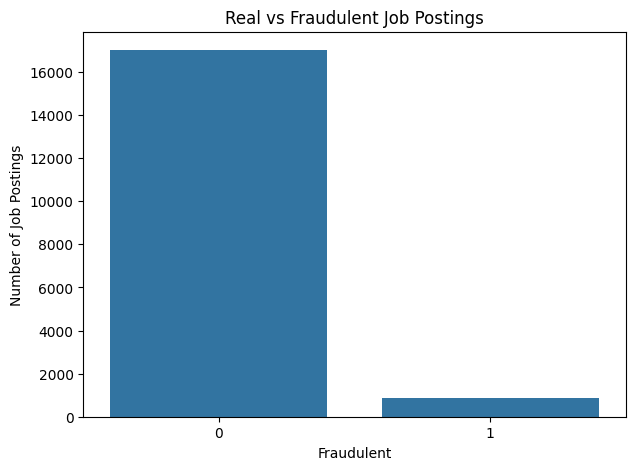

In [14]:
# Visualize the class distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="fraudulent")

plt.title("Real vs Fraudulent Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Number of Job Postings")
plt.show()

In [15]:
# Compare information availability between real and fraudulent job postings

info_features = [
    "has_salary",
    "has_description",
    "has_company_profile",
    "has_requirements",
    "has_benefits",
    "has_location"
]

info_analysis = df.groupby("fraudulent")[info_features].mean().T
info_analysis.columns = ["Real", "Fraudulent"]

info_analysis["Difference"] = (
    info_analysis["Fraudulent"] - info_analysis["Real"]
)

info_analysis.sort_values("Difference", ascending=False)

,Real,Fraudulent,Difference
has_salary,0.155460,0.257506,0.102046
has_description,1.000000,0.998845,-0.001155
has_location,0.980781,0.978060,-0.002720
has_benefits,0.597508,0.579677,-0.017831
has_requirements,0.850594,0.822171,-0.028423
has_company_profile,0.840073,0.322171,-0.517902


In [16]:
# Analyze fraud rates by industry while excluding small categories

industry_summary = (
    df.groupby("industry")["fraudulent"]
    .agg(count="count", fraud_rate="mean")
    .query("count >= 100")
    .sort_values("fraud_rate", ascending=False)
)

industry_summary["fraud_rate"] = industry_summary["fraud_rate"] * 100

industry_summary

,count,fraud_rate
industry,,
Oil & Energy,287,37.979094
Accounting,159,35.849057
Real Estate,175,13.714286
"Health, Wellness and Fitness",127,11.811024
Hospital & Health Care,497,10.261569
Telecommunications,342,7.602339
Consumer Services,358,6.703911
Staffing and Recruiting,127,6.299213
Unknown,4903,5.608811


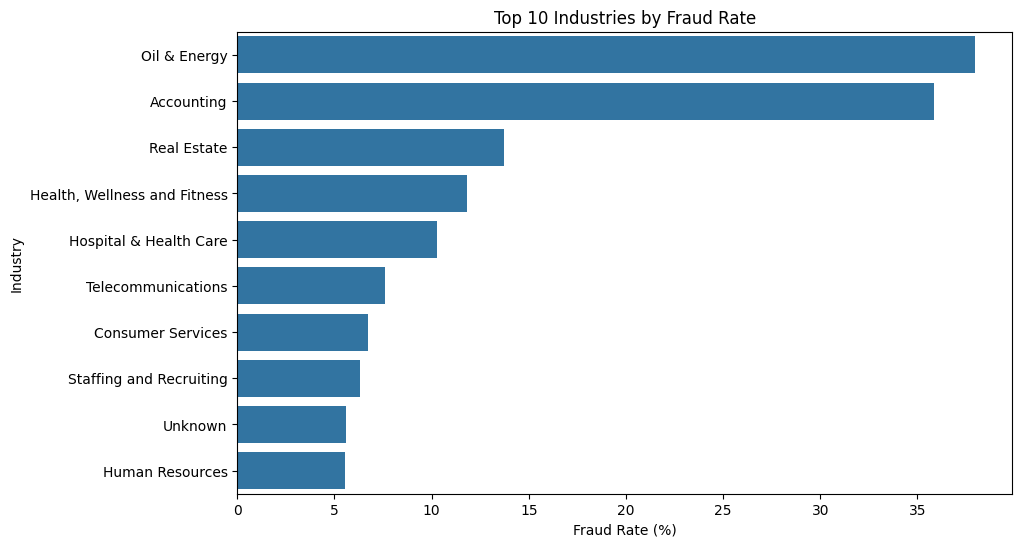

In [17]:
# Visualize the top 10 industries by fraud rate

top_industry_plot = industry_summary.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_industry_plot.reset_index(),
    x="fraud_rate",
    y="industry"
)

plt.title("Top 10 Industries by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Industry")
plt.show()

In [18]:
# Descriptive statistics for information availability features

numeric_features = [
    "missing_fields_count",
    "has_salary",
    "has_description",
    "has_company_profile",
    "has_requirements",
    "has_benefits",
    "has_location"
]

# Overall descriptive statistics
descriptive_stats = (
    df[numeric_features]
    .agg(["mean", "median", "std"])
    .T
)

descriptive_stats

,mean,median,std
missing_fields_count,3.920973,3.0,2.551854
has_salary,0.160403,0.0,0.366989
has_description,0.999944,1.0,0.007479
has_company_profile,0.814989,1.0,0.388317
has_requirements,0.849217,1.0,0.357847
has_benefits,0.596644,1.0,0.490585
has_location,0.980649,1.0,0.137760


In [19]:
# Correlation Analysis
correlation_features = [
    "fraudulent",
    "missing_fields_count",
    "has_salary",
    "has_description",
    "has_company_profile",
    "has_requirements",
    "has_benefits",
    "has_location"
]

correlation_matrix = df[correlation_features].corr()
correlation_matrix


,fraudulent,missing_fields_count,has_salary,has_description,has_company_profile,has_requirements,has_benefits,has_location
fraudulent,1.000000,0.065588,0.059696,-0.033149,-0.286330,-0.017052,-0.007803,-0.004240
missing_fields_count,0.065588,1.000000,-0.396109,-0.020747,-0.264405,-0.503781,-0.494754,-0.215957
has_salary,0.059696,-0.396109,1.000000,0.003269,-0.086105,0.075148,0.129802,0.037061
has_description,-0.033149,-0.020747,0.003269,1.000000,0.015697,0.017748,0.009096,-0.001051
has_company_profile,-0.286330,-0.264405,-0.086105,0.015697,1.000000,0.102723,0.099736,-0.002106
has_requirements,-0.017052,-0.503781,0.075148,0.017748,0.102723,1.000000,0.426144,0.140494
has_benefits,-0.007803,-0.494754,0.129802,0.009096,0.099736,0.426144,1.000000,0.091399
has_location,-0.004240,-0.215957,0.037061,-0.001051,-0.002106,0.140494,0.091399,1.000000


In [20]:
# Correlation of numerical features with the fraud target
correlation_features = [
    "missing_fields_count",
    "has_salary",
    "has_description",
    "has_company_profile",
    "has_requirements",
    "has_benefits",
    "has_location"
]

target_correlations = (
    df[correlation_features + ["fraudulent"]]
    .corr()["fraudulent"]
    .drop("fraudulent")
    .sort_values(ascending=False)
)

target_correlations

,fraudulent
missing_fields_count,0.065588
has_salary,0.059696
has_location,-0.004240
has_benefits,-0.007803
has_requirements,-0.017052
has_description,-0.033149
has_company_profile,-0.286330


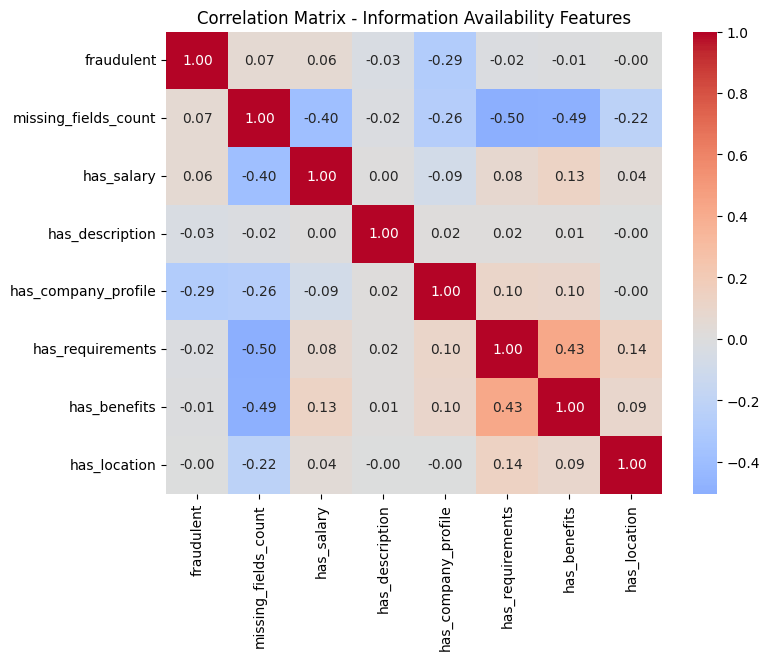

In [21]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix - Information Availability Features")
plt.show()

Correlation analysis shows that `has_company_profile` has the strongest relationship with fraud (`r = -0.286`), while `missing_fields_count` (`r = 0.066`) and `has_salary` (`r = 0.060`) show weak positive relationships. The remaining features have negligible correlations with the target.

In [22]:
# Analyze fraud rates by job function while excluding small categories

function_summary = (
    df.groupby("function")["fraudulent"]
    .agg(count="count", fraud_rate="mean")
    .query("count >= 100")
    .sort_values("fraud_rate", ascending=False)
)

function_summary["fraud_rate"] *= 100

function_summary

,count,fraud_rate
function,,
Administrative,630,18.888889
Accounting/Auditing,212,13.679245
Other,325,9.846154
Finance,172,8.720930
Engineering,1348,8.382789
Business Development,228,5.701754
Project Management,183,5.464481
Customer Service,1229,5.451587
Unknown,6455,5.220759


## Text Analysis

In [23]:
# Text Analysis - Compare text length between real and fraudulent postings

word_count_columns = [
    "description",
    "requirements",
    "company_profile",
    "benefits"
]

# Calculate word count for each text field
for col in word_count_columns:
    df[f"{col}_word_count"] = df[col].str.split().str.len()

word_count_stats = (
    df.groupby("fraudulent")[
        [f"{col}_word_count" for col in word_count_columns]
    ]
    .agg(["mean", "median", "std"])
)

word_count_stats

description_word_count                    requirements_word_count  \
                             mean median         std                    mean   
fraudulent                                                                     
0                      170.435289  147.0  122.350714               78.709651   
1                      157.541570  113.0  135.986743               58.173210   

                             company_profile_word_count                    \
           median        std                       mean median        std   
fraudulent                                                                  
0            63.0  81.587090                  95.584342   86.0  85.364336   
1            34.0  72.797462                  32.167436    1.0  51.736714   

           benefits_word_count                    
                          mean median        std  
fraudulent                                        
0                    30.229870    6.0  49.061346  
1                    29.505774    5.0  52.600517

Text length analysis shows that fraudulent postings tend to have shorter descriptions, requirements, and especially company profiles. The largest difference appears in company_profile, while benefits show nearly identical lengths between real and fraudulent postings.

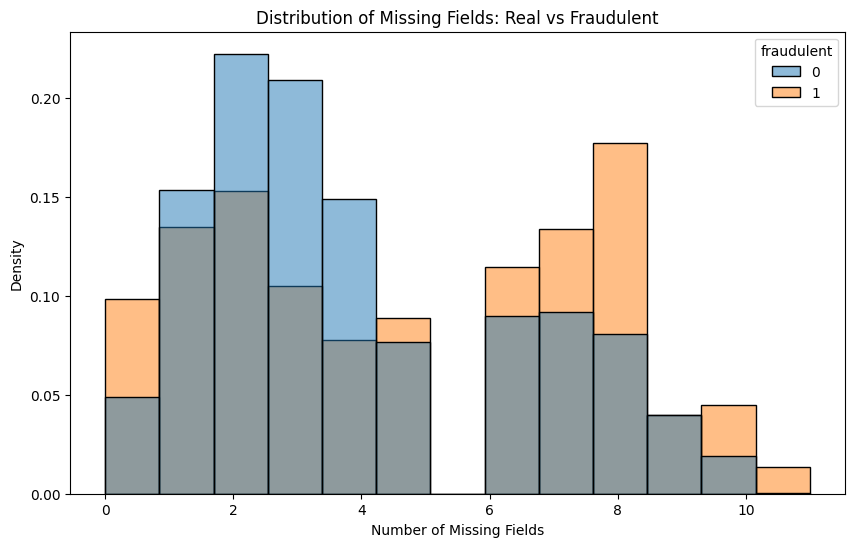

In [24]:
# Distribution of missing fields for real vs fraudulent job postings

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="missing_fields_count",
    hue="fraudulent",
    bins=13,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.title("Distribution of Missing Fields: Real vs Fraudulent")
plt.xlabel("Number of Missing Fields")
plt.ylabel("Density")
plt.show()

The distribution is bimodal for both classes, with peaks around 2–3 and 7–8 missing fields. However, real postings are relatively more concentrated in the lower peak (2–4 missing fields), while fraudulent postings show relatively greater density in the higher peak (6–9 missing fields) — consistent with the earlier finding that fraudulent postings average more missing fields overall (4.66 vs 3.88).

## Key EDA Findings

1. **Class imbalance:** The dataset is highly imbalanced, with only 4.8% of postings (866 of 17,880) being fraudulent. Therefore, model evaluation should use metrics beyond accuracy, such as Precision, Recall, F1-score, and PR-AUC.

2. **Company profile is the strongest signal:** `has_company_profile` shows the strongest correlation with fraud (r = -0.286) among the information-availability features. Fraudulent postings are much less likely to include a company profile (32% vs 84%).

3. **Missing information is associated with fraud:** Fraudulent postings have a higher average number of missing fields (4.66 vs 3.88) and a higher median (5 vs 3). However, the correlation with fraud is weak (r = 0.066).

4. **Salary presence is a notable signal:** Fraudulent postings are more likely to include salary information (25.8% vs 15.5%). This makes salary presence a potentially useful predictive feature.

5. **Some industries and functions have higher fraud rates:** Among categories with at least 100 postings, Oil & Energy (38%) and Accounting (36%) have the highest industry-level fraud rates, while Administrative (18.9%) and Accounting/Auditing (13.7%) have the highest function-level fraud rates.

6. **Small categories can be misleading:** Very small categories may show extremely high fraud rates because of their limited sample size. For example, "Some High School Coursework" has a 74% fraud rate but is based on only 27 postings.

7. **Fraudulent postings tend to contain shorter text:** Fraudulent postings have lower median word counts in descriptions (113 vs 147) and requirements (34 vs 63). Benefits show little difference (5 vs 6 words).

# Model Experiments & Comparison

In this section, different machine learning models are trained and evaluated using the same preprocessing pipeline.

# Baseline - Categorical Encoding + Numerical Features Only


In [25]:
# Categorical Encoding + Numerical Features Only

# Features
categorical_features = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

numeric_features = [
    "title_len",
    "description_len",
    "has_salary",
    "has_description",
    "has_benefits",
    "has_location",
    "has_company_profile",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

target = "fraudulent"

In [26]:
# test/train split
X = df[categorical_features + numeric_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

In [28]:
# Logistic Regression

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logreg_pipeline.fit(X_train, y_train)

y_pred = logreg_pipeline.predict(X_test)
y_score = logreg_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      3403
           1       0.23      0.81      0.35       173

    accuracy                           0.86      3576
   macro avg       0.61      0.83      0.64      3576
weighted avg       0.95      0.86      0.89      3576

ROC-AUC: 0.9116488511496996


In [29]:
# Linear SVC

svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(
        class_weight="balanced",
        max_iter=10000,
        random_state=42
    ))
])

svc_pipeline.fit(X_train, y_train)

y_pred = svc_pipeline.predict(X_test)
y_score = svc_pipeline.decision_function(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      3403
           1       0.22      0.79      0.34       173

    accuracy                           0.85      3576
   macro avg       0.60      0.82      0.63      3576
weighted avg       0.95      0.85      0.89      3576

ROC-AUC: 0.902472996455015


In [30]:
# Random Forest

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
y_score = rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.96      0.62      0.75       173

    accuracy                           0.98      3576
   macro avg       0.97      0.81      0.87      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9560359016780502


In [31]:
# XGBoost

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)
y_score = xgb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.91      0.54      0.68       173

    accuracy                           0.98      3576
   macro avg       0.94      0.77      0.83      3576
weighted avg       0.97      0.98      0.97      3576

ROC-AUC: 0.9554048705749263


In [32]:
# Decision Tree

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred = dt_pipeline.predict(X_test)
y_score = dt_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.71      0.70      0.70       173

    accuracy                           0.97      3576
   macro avg       0.85      0.84      0.84      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.8423645236522008


In [33]:
# Complement Naive Bayes

cnb_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", MinMaxScaler(), numeric_features)
    ]
)

cnb_pipeline = Pipeline([
    ("preprocessor", cnb_preprocessor),
    ("classifier", ComplementNB())
])

cnb_pipeline.fit(X_train, y_train)

y_pred = cnb_pipeline.predict(X_test)
y_score = cnb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.98      0.77      0.86      3403
           1       0.14      0.76      0.24       173

    accuracy                           0.77      3576
   macro avg       0.56      0.77      0.55      3576
weighted avg       0.94      0.77      0.83      3576

ROC-AUC: 0.8553928104919325


In [34]:
# Model Comparison

results = []

models = {
    "Logistic Regression": logreg_pipeline,
    "Linear SVC": svc_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "Decision Tree": dt_pipeline,
    "Complement NB": cnb_pipeline
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

results_df = pd.DataFrame(results).sort_values(
    "F1-Score",
    ascending=False
)

results_df

,Model,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.963964,0.618497,0.753521,0.956036
4,Decision Tree,0.707602,0.699422,0.703488,0.842365
3,XGBoost,0.911765,0.537572,0.676364,0.955405
0,Logistic Regression,0.225080,0.809249,0.352201,0.911649
1,Linear SVC,0.219200,0.791908,0.343358,0.902473
5,Complement NB,0.143791,0.763006,0.241980,0.855393


## Baseline — Categorical + Numerical Features

In this experiment, only categorical and numerical features were used, without text features.

Categorical features were transformed using One-Hot Encoding, while numerical features were scaled before being passed to the classifiers.

Six machine learning models were evaluated without hyperparameter tuning:

- Logistic Regression
- Linear SVC
- Random Forest
- XGBoost
- Decision Tree
- Complement Naive Bayes

### Results

The models were compared using Precision, Recall, F1-Score, and ROC-AUC.

This experiment evaluates how well the structured categorical and numerical features can detect fraudulent job postings without using text information.

### Conclusion

The best-performing model was selected based on the highest F1-Score, as F1-Score provides a balance between Precision and Recall and is appropriate for the imbalanced dataset.

## Ordinal Encoding + Numerical Features

In the second experiment, the same categorical and numerical features from EX1 were used, but the categorical features were encoded using **Ordinal Encoding** instead of One-Hot Encoding.


In [37]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=999
            ),
            categorical_features
        ),
        ("num", StandardScaler(), numeric_features)
    ]
)

In [40]:
models_ordinal = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Linear SVC": LinearSVC(
        class_weight="balanced",
        max_iter=10000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "Complement NB": ComplementNB()
}

results_ordinal = []

for name, model in models_ordinal.items():

    if name == "Complement NB":
        current_preprocessor = ColumnTransformer(
            transformers=[
                ("cat", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=999
                ), categorical_features),
                ("num", MinMaxScaler(), numeric_features)
            ]
        )
    else:
        current_preprocessor = ordinal_preprocessor

    pipeline = Pipeline([
        ("preprocessor", current_preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)

    results_ordinal.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

results_ordinal_df = pd.DataFrame(results_ordinal).sort_values(
    "F1-Score",
    ascending=False
)

results_ordinal_df

,Model,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.936364,0.595376,0.727915,0.949724
3,XGBoost,0.888889,0.554913,0.683274,0.963441
4,Decision Tree,0.636364,0.647399,0.641834,0.814296
1,Linear SVC,0.159639,0.612717,0.253286,0.796951
0,Logistic Regression,0.154286,0.624277,0.247423,0.797258
5,Complement NB,0.079968,0.583815,0.140669,0.673342


### Conclusion

Random Forest achieved the highest **F1-Score (0.728)** and the highest **Precision (0.936)** among the evaluated models.

XGBoost achieved the highest **ROC-AUC (0.963)**.

Compared with EX1, the best F1-Score decreased from **0.754 to 0.728**, and the linear models showed a clear performance degradation.

Therefore, **One-Hot Encoding performed better than Ordinal Encoding** on this dataset. Ordinal Encoding is kept as a comparison experiment.

## EX1 — Classical ML with TF-IDF

In the first experiment, we used a classical Machine Learning approach combining text, categorical, and numerical features.

### Features

- **Text:** `job_context` using **TF-IDF** with unigrams and bigrams.
- **Categorical:** `employment_type`, `required_experience`, `required_education`, `industry`, `function` using **One-Hot Encoding**.
- **Numerical:** text-length and information-availability features such as `title_len`, `description_len`, `has_salary`, `has_company_profile`, and `has_location`.


In [ ]:
# Define features for preprocessing

text_feature = "job_context"

categorical_features = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

numeric_features = [
    "title_len",
    "description_len",
    "has_salary",
    "has_description",
    "has_benefits",
    "has_location",
    "has_company_profile",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

target = "fraudulent"

In [ ]:
# Prepare data for modeling

X = df[[text_feature] + categorical_features + numeric_features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (14304, 16)
Testing shape: (3576, 16)


In [ ]:
# Preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            min_df=1,
            stop_words="english"
        ), text_feature),

        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# Logistic Regression pipeline

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced",max_iter=1000,random_state=42))
])

In [ ]:
# Hyperparameter tuning

logreg_params = {
    "classifier__C": [ 10, 100]
}
logreg_grid = GridSearchCV(
    logreg_pipeline,
    param_grid=logreg_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

print("Best Parameters:", logreg_grid.best_params_)
print("Best CV F1:", logreg_grid.best_score_)

Best Parameters: {'classifier__C': 100}
Best CV F1: 0.6771925811848174


In [ ]:
# Evaluate tuned Logistic Regression

best_logreg = logreg_grid.best_estimator_

y_pred = best_logreg.predict(X_test)
y_prob = best_logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3403
           1       0.71      0.73      0.72       173

    accuracy                           0.97      3576
   macro avg       0.85      0.86      0.85      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.9460302793013307


In [ ]:
# LinearSVC pipeline
svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(
    class_weight="balanced",
    max_iter=10000,
    random_state=42
))
])

In [ ]:
# LinearSVC hyperparameter tuning
svc_params = {
    "classifier__C": [0.1, 1, 10, 100]
}

svc_grid = GridSearchCV(
    svc_pipeline,
    param_grid=svc_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svc_grid.fit(X_train, y_train)

print("Best Parameters:", svc_grid.best_params_)
print("Best CV F1:", svc_grid.best_score_)

Best Parameters: {'classifier__C': 1}
Best CV F1: 0.6714141873586768


In [ ]:
# Evaluate tuned LinearSVC

best_svc = svc_grid.best_estimator_
y_pred = best_svc.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_svc.decision_function(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3403
           1       0.66      0.77      0.71       173

    accuracy                           0.97      3576
   macro avg       0.82      0.87      0.85      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.958124334359856


In [ ]:
# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

In [ ]:
# Random Forest hyperparameter tuning
rf_params = {
    "classifier__n_estimators": [200],
    "classifier__max_depth": [None, 20],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1: 0.7006095913531196


In [ ]:
# Evaluate tuned Random Forest
best_rf = rf_grid.best_estimator_
y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.60      0.75       173

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9762254997715378


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
best_rf.fit(X_tr, y_tr)
val_prob = best_rf.predict_proba(X_val)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
for t in thresholds:
    pred = (val_prob >= t).astype(int)
    print(t, "Precision:", round(precision_score(y_val, pred), 3),
          "Recall:", round(recall_score(y_val, pred), 3),
          "F1:", round(f1_score(y_val, pred), 3))

0.3 Precision: 0.715 Recall: 0.705 F1: 0.71
0.35 Precision: 0.762 Recall: 0.669 F1: 0.713
0.4 Precision: 0.888 Recall: 0.626 F1: 0.734
0.45 Precision: 0.929 Recall: 0.568 F1: 0.705
0.5 Precision: 0.949 Recall: 0.54 F1: 0.688
0.55 Precision: 0.971 Recall: 0.482 F1: 0.644
0.6 Precision: 0.969 Recall: 0.446 F1: 0.611


In [ ]:
# XGBoost pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(eval_metric="logloss",random_state=42,n_jobs=-1))
])

In [ ]:
# XGBoost hyperparameter tuning

xgb_params = {
    "classifier__n_estimators": [200],
    "classifier__max_depth": [3, 6],
    "classifier__learning_rate": [0.1]
}
xgb_grid = GridSearchCV(
    xgb_pipeline,
    param_grid=xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200}
Best CV F1: 0.6733135245064876


In [ ]:
# Evaluate tuned XGBoost
best_xgb = xgb_grid.best_estimator_
y_pred = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.94      0.55      0.69       173

    accuracy                           0.98      3576
   macro avg       0.96      0.77      0.84      3576
weighted avg       0.98      0.98      0.97      3576

ROC-AUC: 0.9657756926479356


In [ ]:
# Decision Tree pipeline
from sklearn.tree import DecisionTreeClassifier
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [ ]:
# Decision Tree hyperparameter tuning

dt_params = {
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}
dt_grid = GridSearchCV(
    dt_pipeline,
    param_grid=dt_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV F1:", dt_grid.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV F1: 0.6554921179053045


In [ ]:
# Evaluate tuned Decision Tree

best_dt = dt_grid.best_estimator_
y_pred = best_dt.predict(X_test)
y_prob = best_dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.75      0.69      0.72       173

    accuracy                           0.97      3576
   macro avg       0.86      0.84      0.85      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.8407967128630127


In [ ]:
from sklearn.preprocessing import MinMaxScaler

cnb_preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            min_df=1,
            stop_words="english"
        ), text_feature),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", MinMaxScaler(), numeric_features)
    ]
)

In [ ]:
# Complement Naive Bayes pipeline
cnb_pipeline = Pipeline([
    ("preprocessor", cnb_preprocessor),
    ("classifier", ComplementNB())
])

In [ ]:
cnb_params = {
    "classifier__alpha": [0.1, 0.5, 1.0, 2.0]
}

cnb_grid = GridSearchCV(
    cnb_pipeline,
    param_grid=cnb_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

cnb_grid.fit(X_train, y_train)

print("Best Parameters:", cnb_grid.best_params_)
print("Best CV F1:", cnb_grid.best_score_)

Best Parameters: {'classifier__alpha': 0.1}
Best CV F1: 0.5607638951808563


In [ ]:
best_cnb = cnb_grid.best_estimator_

y_pred = best_cnb.predict(X_test)
y_prob = best_cnb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3403
           1       0.44      0.75      0.56       173

    accuracy                           0.94      3576
   macro avg       0.72      0.85      0.76      3576
weighted avg       0.96      0.94      0.95      3576

ROC-AUC: 0.9226422113096402


In [ ]:
# EX1 Dynamic Model Comparison

models = {
    "Logistic Regression": best_logreg,
    "Linear SVC": best_svc,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "Decision Tree": best_dt,
    "Complement NB": best_cnb
}

results_ex1 = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results_ex1.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

results_ex1 = pd.DataFrame(results_ex1)
results_ex1.sort_values("F1", ascending=False)

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.705556,0.734104,0.719547,0.946030
4,Decision Tree,0.745342,0.693642,0.718563,0.840797
1,Linear SVC,0.661692,0.768786,0.711230,0.958124
2,Random Forest,0.989583,0.549133,0.706320,0.974781
3,XGBoost,0.940594,0.549133,0.693431,0.965776
5,Complement NB,0.444828,0.745665,0.557235,0.922642


## EX1 — Classical Machine Learning

In the first experiment, six classical machine learning models were evaluated using the same dataset split and preprocessing approach.

The feature set combines:
- TF-IDF features from `job_context`
- One-Hot Encoded categorical features
- Numerical and information-availability features


### EX1 Conclusion

Six classical machine learning models were evaluated using the same dataset split and preprocessing approach.

Logistic Regression achieved the highest F1-score (0.720), providing the best overall F1 performance in EX1.

Decision Tree achieved a similar F1-score (0.719), while Linear SVC achieved the highest recall (0.769), making it effective at identifying fraudulent job postings.

Random Forest achieved very high precision (0.990) and a strong ROC-AUC (0.975), but its recall was lower (0.549).

Overall, Logistic Regression provided the best F1-score in EX1, while Linear SVC provided the highest recall.

## EX2 — Text + Numerical Features

In the second experiment, we combined the main text fields into a single text feature and removed the One-Hot Encoding of categorical features.

### Features

- **Text:** `title`, `description`, `requirements`, and `benefits` were combined into `text_combined` and transformed using **TF-IDF**.
- **Numerical:** text-length and information-availability features were included.# EX2

In [ ]:
# EX2 Preprocessing - No One-Hot Encoding
df["text_combined"] = (
    df["title"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

text_feature = "text_combined"
numeric_features = [
    "title_len",
    "description_len",
    "has_salary",
    "has_description",
    "has_benefits",
    "has_location",
    "has_company_profile",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

target = "fraudulent"

X = df[[text_feature] + numeric_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            min_df=1,
            stop_words="english"
        ), text_feature),

        ("num", StandardScaler(), numeric_features)
    ]
)

print("EX2 Preprocessing created successfully.")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

EX2 Preprocessing created successfully.
Training shape: (14304, 11)
Testing shape: (3576, 11)


In [ ]:
# Logistic Regression - EX2

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logreg_params = {
    "classifier__C": [0.1, 1, 10, 100]
}

logreg_grid = GridSearchCV(
    logreg_pipeline,
    param_grid=logreg_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

print("Best Parameters:", logreg_grid.best_params_)
print("Best CV F1:", logreg_grid.best_score_)

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'classifier__C': 100}
Best CV F1: 0.751032328955081


In [ ]:
# Evaluate EX2 Logistic Regression

best_logreg = logreg_grid.best_estimator_

y_pred = best_logreg.predict(X_test)
y_prob = best_logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.84      0.80      0.82       173

    accuracy                           0.98      3576
   macro avg       0.92      0.90      0.91      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9832093069868647


In [ ]:
# Linear SVC - EX2

svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    ))
])

svc_params = {
    "classifier__C": [0.1, 10, 100]
}

svc_grid = GridSearchCV(
    svc_pipeline,
    param_grid=svc_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

svc_grid.fit(X_train, y_train)

print("Best Parameters:", svc_grid.best_params_)
print("Best CV F1:", svc_grid.best_score_)

Best Parameters: {'classifier__C': 10}
Best CV F1: 0.7600787585307708


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
# Evaluate EX2 Linear SVC

best_svc = svc_grid.best_estimator_

y_pred = best_svc.predict(X_test)
y_score = best_svc.decision_function(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.88      0.76      0.81       173

    accuracy                           0.98      3576
   macro avg       0.93      0.88      0.90      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9793432860159091


In [ ]:
# Random Forest - EX2

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "classifier__n_estimators": [70, 200],
    "classifier__max_depth": [None, 20],
    "classifier__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV F1: 0.6765763384243


In [ ]:
# Evaluate EX2 Random Forest

best_rf = rf_grid.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.81      0.62      0.71       173

    accuracy                           0.97      3576
   macro avg       0.90      0.81      0.85      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.9755231273323945


In [ ]:
# XGBoost - EX2

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_params = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [3, 6],
    "classifier__learning_rate": [0.1]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    param_grid=xgb_params,
    cv=2,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 100}
Best CV F1: 0.653471907369302


In [ ]:
best_xgb = xgb_grid.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.98      0.61      0.75       173

    accuracy                           0.98      3576
   macro avg       0.98      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9775444651862772


In [ ]:
# Decision Tree - EX2

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_params = {
    "classifier__max_depth": [10, None],
    "classifier__min_samples_split": [2, 5]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    param_grid=dt_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best CV F1:", dt_grid.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5}
Best CV F1: 0.6498944183837013


In [ ]:
# Evaluate EX2 Decision Tree

best_dt = dt_grid.best_estimator_
y_pred = best_dt.predict(X_test)
y_prob = best_dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3403
           1       0.68      0.72      0.70       173

    accuracy                           0.97      3576
   macro avg       0.83      0.85      0.84      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.8619103511182754


In [ ]:
# EX2 - Complement NB preprocessing

cnb_preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=1,
        stop_words="english"
    ), text_feature),

    ("num", MinMaxScaler(), numeric_features)
])

In [ ]:
cnb_pipeline = Pipeline([
    ("preprocessor", cnb_preprocessor),
    ("classifier", ComplementNB())
])

In [ ]:
cnb_params = {
    "classifier__alpha": [0.1, 0.5, 1.0]
}

cnb_grid = GridSearchCV(
    cnb_pipeline,
    param_grid=cnb_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

cnb_grid.fit(X_train, y_train)

print("Best Parameters:", cnb_grid.best_params_)
print("Best CV F1:", cnb_grid.best_score_)

Best Parameters: {'classifier__alpha': 0.1}
Best CV F1: 0.5530194732926667


In [ ]:
best_cnb = cnb_grid.best_estimator_

y_pred = best_cnb.predict(X_test)
y_prob = best_cnb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3403
           1       0.46      0.88      0.60       173

    accuracy                           0.94      3576
   macro avg       0.73      0.92      0.79      3576
weighted avg       0.97      0.94      0.95      3576

ROC-AUC: 0.9733081487093163


In [ ]:
# EX2 - Model Comparison

models = {
    "Logistic Regression": best_logreg,
    "Linear SVC": best_svc,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "Decision Tree": best_dt,
    "Complement NB": best_cnb
}

results_ex2 = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results_ex2.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

results_ex2 = pd.DataFrame(results_ex2).sort_values("F1", ascending=False)
results_ex2.round(3)

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.842,0.803,0.822,0.983
1,Linear SVC,0.879,0.757,0.814,0.979
3,XGBoost,0.981,0.607,0.750,0.978
2,Random Forest,0.812,0.624,0.706,0.976
4,Decision Tree,0.679,0.723,0.700,0.862
5,Complement NB,0.458,0.884,0.604,0.973


### EX2 Conclusion

Logistic Regression achieved the highest F1-score (0.822) and the highest ROC-AUC (0.983), providing the best overall performance in EX2.

Linear SVC achieved the second-highest F1-score (0.814) and a relatively high precision (0.879).

Complement Naive Bayes achieved the highest recall (0.884), but its precision was considerably lower (0.458), resulting in a lower F1-score.

Overall, Logistic Regression provided the best balance between precision and recall in EX2.

## EX3 — Handling Class Imbalance

In the third experiment, the focus was on handling the class imbalance in the dataset.

The same text and numerical features from EX2 were used, while different resampling techniques were applied to the training data to improve the detection of fraudulent job postings.

### Resampling Techniques

Two approaches were compared:

- **Random Over-Sampling (ROS)** — duplicates samples from the minority class.
- **SMOTE** — generates synthetic samples for the minority class.

These techniques were evaluated with several Machine Learning models to determine their effect on fraud detection performance.

In [ ]:
# EX3 Preprocessing
# Define features for preprocessing

df["text_context"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["requirements"].fillna("") + " " +
    df["benefits"].fillna("")
)

text_feature = "text_context"

numeric_features = [
    "title_len",
    "description_len",
    "has_salary",
    "has_location",
    "has_company_profile",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

target = "fraudulent"


In [ ]:
X = df[[text_feature] + numeric_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            min_df=1,
            stop_words="english"
        ), text_feature),

        ("num", StandardScaler(), numeric_features)
    ]
)

print("EX3 Preprocessing created successfully.")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

EX3 Preprocessing created successfully.
Training shape: (14304, 9)
Testing shape: (3576, 9)


In [ ]:
# logitic EX3
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logreg_params = {
    "classifier__C": [1, 10, 100]
}

logreg_grid = GridSearchCV(
    logreg_pipeline,
    param_grid=logreg_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

print("Best Parameters:", logreg_grid.best_params_)
print("Best CV F1:", logreg_grid.best_score_)

Best Parameters: {'classifier__C': 100}
Best CV F1: 0.7638926379061969


In [ ]:
# Evaluate EX3 Logistic Regression

smote_logreg = logreg_grid.best_estimator_
y_pred = smote_logreg.predict(X_test)
y_prob = smote_logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.87      0.79      0.82       173

    accuracy                           0.98      3576
   macro avg       0.93      0.89      0.91      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9844051236668089


In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros_logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=42)),
    ("classifier", LogisticRegression(
        C=100,
        max_iter=2000,
        random_state=42
    ))
])

ros_logreg.fit(X_train, y_train)

y_pred_ros = ros_logreg.predict(X_test)
y_prob_ros = ros_logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_ros))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_ros))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.87      0.79      0.82       173

    accuracy                           0.98      3576
   macro avg       0.93      0.89      0.91      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9849860459743953


In [ ]:
# Random Forest with SMOTE
smote_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=70,
        max_depth=20,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
smote_rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = smote_rf.predict(X_test)
y_prob = smote_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.60      0.75       173

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9739604123529222


In [ ]:
# Random Forest with RandomOverSampler
ros_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
ros_rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = ros_rf.predict(X_test)
y_prob = ros_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3403
           1       0.71      0.75      0.73       173

    accuracy                           0.97      3576
   macro avg       0.85      0.87      0.86      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.9802282583031973


In [ ]:
# XGBoost with SMOTE
smote_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
smote_xgb.fit(X_train, y_train)

# Predict and evaluate
y_pred = smote_xgb.predict(X_test)
y_prob = smote_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.88      0.69      0.77       173

    accuracy                           0.98      3576
   macro avg       0.93      0.84      0.88      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9616608263025314


In [ ]:
# XGBoost with RandomOverSampler
ros_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=42)),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
ros_xgb.fit(X_train, y_train)

# Predict and evaluate
y_pred = ros_xgb.predict(X_test)
y_prob = ros_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.58      0.82      0.68       173

    accuracy                           0.96      3576
   macro avg       0.79      0.90      0.83      3576
weighted avg       0.97      0.96      0.97      3576

ROC-AUC: 0.9743035302071108


In [ ]:
# Linear SVC with SMOTE
smote_svc = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ("classifier", LinearSVC(C=10, max_iter=10000))
])

# Train
smote_svc.fit(X_train, y_train)

# Predict and evaluate
y_pred = smote_svc.predict(X_test)
y_score = smote_svc.decision_function(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.89      0.77      0.83       173

    accuracy                           0.98      3576
   macro avg       0.94      0.88      0.91      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9801365337283151


In [ ]:
# Linear SVC with RandomOverSampler
ros_svc = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=42)),
    ("classifier", LinearSVC(C=10, max_iter=10000))
])

# Train
ros_svc.fit(X_train, y_train)

# Predict and evaluate
y_pred = ros_svc.predict(X_test)
y_score = ros_svc.decision_function(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.89      0.76      0.82       173

    accuracy                           0.98      3576
   macro avg       0.94      0.88      0.91      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC: 0.9801433281412694


In [ ]:
# Decision Tree with SMOTE
smote_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ("classifier", DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        random_state=42
    ))
])

# Train
smote_dt.fit(X_train, y_train)

# Predict and evaluate
y_pred = smote_dt.predict(X_test)
y_prob = smote_dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.59      0.73      0.65       173

    accuracy                           0.96      3576
   macro avg       0.79      0.85      0.82      3576
weighted avg       0.97      0.96      0.96      3576

ROC-AUC: 0.8515259402193576


In [ ]:
# Decision Tree with RandomOverSampler
ros_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=42)),
    ("classifier", DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        random_state=42
    ))
])

# Train
ros_dt.fit(X_train, y_train)

# Predict and evaluate
y_pred = ros_dt.predict(X_test)
y_prob = ros_dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3403
           1       0.64      0.69      0.66       173

    accuracy                           0.97      3576
   macro avg       0.81      0.83      0.82      3576
weighted avg       0.97      0.97      0.97      3576

ROC-AUC: 0.8339394515889584


In [ ]:
# EX3 - Oversampling Comparison

models_ex3 = {
    "Logistic Regression + SMOTE": smote_logreg,
    "Logistic Regression + ROS": ros_logreg,
    "Linear SVC + SMOTE": smote_svc,
    "Linear SVC + ROS": ros_svc,
    "Random Forest + SMOTE": smote_rf,
    "Random Forest + ROS": ros_rf,
    "XGBoost + SMOTE": smote_xgb,
    "XGBoost + ROS": ros_xgb,
    "Decision Tree + SMOTE": smote_dt,
    "Decision Tree + ROS": ros_dt
}

results_ex3 = []

for name, model in models_ex3.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results_ex3.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

results_ex3 = (
    pd.DataFrame(results_ex3)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

results_ex3.round(3)

,Model,Precision,Recall,F1,ROC-AUC
0,Linear SVC + SMOTE,0.893,0.769,0.826,0.980
1,Logistic Regression + SMOTE,0.866,0.786,0.824,0.984
2,Logistic Regression + ROS,0.866,0.786,0.824,0.985
3,Linear SVC + ROS,0.892,0.763,0.822,0.980
4,XGBoost + SMOTE,0.876,0.694,0.774,0.962
5,Random Forest + SMOTE,1.000,0.601,0.751,0.974
6,Random Forest + ROS,0.707,0.751,0.728,0.980
7,XGBoost + ROS,0.580,0.821,0.679,0.974
8,Decision Tree + ROS,0.636,0.688,0.661,0.834
9,Decision Tree + SMOTE,0.594,0.728,0.655,0.852


# EX4: Ensemble Learning

In this experiment, ensemble learning is used to combine the predictions of the best-performing models from EX3.

Two ensemble methods are evaluated:

- Hard Voting: combines predictions using majority voting.
- Stacking: combines base model predictions using a Logistic Regression meta-learner.

The best-performing variants from EX3 are used as base models to improve the final fraud detection performance.

In [ ]:
# Ensemble models and evaluation metrics
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

In [ ]:
# Hard Voting using the best models from EX3
voting_ex4 = VotingClassifier(
    estimators=[
        ("lr", ros_logreg),
        ("svc", ros_svc),
        ("rf", smote_rf),
        ("xgb", smote_xgb)
    ],
    voting="hard"
)

# Train the Voting ensemble
voting_ex4.fit(X_train, y_train)

# Predictions
voting_pred = voting_ex4.predict(X_test)

print("Voting Accuracy:", accuracy_score(y_test, voting_pred))
print("Voting F1:", f1_score(y_test, voting_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, voting_pred))

Voting Accuracy: 0.9840604026845637
Voting F1: 0.8041237113402062

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.68      0.80       173

    accuracy                           0.98      3576
   macro avg       0.99      0.84      0.90      3576
weighted avg       0.98      0.98      0.98      3576



In [ ]:
# Stacking combines the predictions of several base models
# and uses Logistic Regression as the final meta-learner

stack_ex4 = StackingClassifier(
    estimators=[
        ("lr", ros_logreg),
        ("svc", ros_svc),
        ("rf", smote_rf),
        ("xgb", smote_xgb)
    ],
    final_estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    cv=5
)

# Train the Stacking ensemble
stack_ex4.fit(X_train, y_train)

# Predictions
stack_pred = stack_ex4.predict(X_test)

# Probability scores for ROC-AUC
stack_score = stack_ex4.predict_proba(X_test)[:, 1]

print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))
print("Stacking Precision:", precision_score(y_test, stack_pred))
print("Stacking Recall:", recall_score(y_test, stack_pred))
print("Stacking F1:", f1_score(y_test, stack_pred))
print("Stacking ROC-AUC:", roc_auc_score(y_test, stack_score))

print("\nClassification Report:\n")
print(classification_report(y_test, stack_pred))

Stacking Accuracy: 0.9868568232662193
Stacking Precision: 0.95
Stacking Recall: 0.7687861271676301
Stacking F1: 0.8498402555910544
Stacking ROC-AUC: 0.9831430614605609

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.95      0.77      0.85       173

    accuracy                           0.99      3576
   macro avg       0.97      0.88      0.92      3576
weighted avg       0.99      0.99      0.99      3576



In [ ]:
# Compare the best EX3 model with the ensemble models

models_ex4 = {
    "Logistic Regression + ROS": ros_logreg,
    "Hard Voting": voting_ex4,
    "Stacking": stack_ex4
}

results_ex4 = []

for name, model in models_ex4.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Calculate ROC-AUC only when a continuous score is available
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)

    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)

    else:
        roc_auc = None

    results_ex4.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    })

# Sort models by F1-score
results_ex4 = (
    pd.DataFrame(results_ex4)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

results_ex4.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Stacking,0.987,0.950,0.769,0.850,0.983
1,Logistic Regression + ROS,0.984,0.866,0.786,0.824,0.985
2,Hard Voting,0.984,0.992,0.676,0.804,NaN


### EX4 Conclusion

The **Stacking ensemble** achieved the highest F1-score (0.850), providing the best overall performance among the evaluated ensemble approaches.

Hard Voting achieved the highest precision (0.992), but its recall was lower (0.676), resulting in a lower F1-score.

Overall, Stacking provided the best balance between Precision and Recall and improved the F1-score compared with the individual models evaluated in the previous experiments.

# EX5: Transformer-Based Text Classification

In this experiment, a pre-trained Transformer model is used instead of TF-IDF for text representation.

DistilBERT is fine-tuned to classify job postings as real or fraudulent.

The text fields are combined into a single text input:
- Title
- Company Profile
- Description
- Requirements
- Benefits

The model is evaluated using Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

In [ ]:
!pip install -q transformers

In [ ]:
import torch
import numpy as np
import pandas as pd

from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
text_columns_ex5 = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

# Make sure text fields are strings
for col in text_columns_ex5:
    df[col] = df[col].fillna("").astype(str)

# Combine the text fields
df["text_combined_ex5"] = (
    df["title"] + " "
    + df["company_profile"] + " "
    + df["description"] + " "
    + df["requirements"] + " "
    + df["benefits"]
)

print(df["text_combined_ex5"].head())

0    marketing intern were food52 and weve created ...
1    customer service cloud video production 90 sec...
2    commissioning machinery assistant cma valor se...
3    account executive washington dc our passion fo...
4    bill review manager spotsource solutions llc i...
Name: text_combined_ex5, dtype: object


In [ ]:
numeric_features_ex5 = [
    "title_len",
    "description_len",
    "has_salary",
    "has_description",
    "has_benefits",
    "has_location",
    "has_company_profile",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

X_text = df["text_combined_ex5"]
X_num = df[numeric_features_ex5]
y = df["fraudulent"]

print("Numerical features:")
print(numeric_features_ex5)

Numerical features:
['title_len', 'description_len', 'has_salary', 'has_description', 'has_benefits', 'has_location', 'has_company_profile', 'telecommuting', 'has_company_logo', 'has_questions']


In [ ]:
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text,
    X_num,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 14304
Testing samples: 3576


In [ ]:
scaler_ex5 = StandardScaler()

X_train_num_scaled = scaler_ex5.fit_transform(
    X_train_num
)

X_test_num_scaled = scaler_ex5.transform(
    X_test_num
)

print("Training numerical shape:", X_train_num_scaled.shape)
print("Testing numerical shape:", X_test_num_scaled.shape)

Training numerical shape: (14304, 10)
Testing numerical shape: (3576, 10)


In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

bert_model = AutoModel.from_pretrained(
    model_name
)

bert_model = bert_model.to(device)

# Freeze all DistilBERT parameters
for param in bert_model.parameters():
    param.requires_grad = False

# Evaluation mode
bert_model.eval()

print("DistilBERT loaded.")
print("All DistilBERT parameters are frozen.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded.
All DistilBERT parameters are frozen.


In [ ]:
total_params = sum(
    p.numel()
    for p in bert_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in bert_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 66362880
Trainable parameters: 0


In [ ]:
def mean_pooling(model_output, attention_mask):

    token_embeddings = model_output.last_hidden_state

    input_mask_expanded = (
        attention_mask
        .unsqueeze(-1)
        .expand(token_embeddings.size())
        .float()
    )

    sum_embeddings = torch.sum(
        token_embeddings * input_mask_expanded,
        dim=1
    )

    sum_mask = torch.clamp(
        input_mask_expanded.sum(dim=1),
        min=1e-9
    )

    return sum_embeddings / sum_mask

In [ ]:
def extract_bert_embeddings(
    texts,
    batch_size=16,
    max_length=256
):
    all_embeddings = []

    for start in range(0, len(texts), batch_size):

        batch_texts = texts.iloc[
            start:start + batch_size
        ].tolist()

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        bert_model.eval()

        with torch.no_grad():

            outputs = bert_model(**inputs)

            token_embeddings = outputs.last_hidden_state
            attention_mask = inputs["attention_mask"]

            mask = attention_mask.unsqueeze(-1).expand(
                token_embeddings.size()
            ).float()

            embeddings = (
                torch.sum(token_embeddings * mask, dim=1)
                / torch.clamp(mask.sum(dim=1), min=1e-9)
            )

        all_embeddings.append(
            embeddings.cpu().numpy()
        )

    return np.vstack(all_embeddings)

In [ ]:
X_train_bert = extract_bert_embeddings(
    X_train_text,
    batch_size=16,
    max_length=256
)

X_test_bert = extract_bert_embeddings(
    X_test_text,
    batch_size=16,
    max_length=256
)

X_train_combined = np.hstack([
    X_train_bert,
    X_train_num_scaled
])

X_test_combined = np.hstack([
    X_test_bert,
    X_test_num_scaled
])

print(X_train_combined.shape)
print(X_test_combined.shape)

(14304, 778)
(3576, 778)


In [ ]:
print("Extracting DistilBERT training features...")

X_train_bert = extract_bert_embeddings(
    X_train_text,
    batch_size=16,
    max_length=256
)

print("Training BERT feature shape:")
print(X_train_bert.shape)

Extracting DistilBERT training features...
Training BERT feature shape:
(14304, 768)


In [ ]:
print("Extracting DistilBERT testing features...")

X_test_bert = extract_bert_embeddings(
    X_test_text,
    batch_size=16,
    max_length=256
)

print("Testing BERT feature shape:")
print(X_test_bert.shape)

Extracting DistilBERT testing features...
Testing BERT feature shape:
(3576, 768)


In [ ]:
X_train_combined = np.hstack([
    X_train_bert,
    X_train_num_scaled
])

X_test_combined = np.hstack([
    X_test_bert,
    X_test_num_scaled
])

print("Combined training shape:")
print(X_train_combined.shape)

print("Combined testing shape:")
print(X_test_combined.shape)

Combined training shape:
(14304, 778)
Combined testing shape:
(3576, 778)


In [ ]:
models_ex5 = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVC": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )
}

In [ ]:
results_ex5 = []

for name, model in models_ex5.items():

    print(f"\nTraining {name}...")

    # Train classifier only
    model.fit(
        X_train_combined,
        y_train
    )

    # Predictions
    y_pred = model.predict(
        X_test_combined
    )

    # Scores for ROC-AUC and PR-AUC
    if hasattr(model, "predict_proba"):

        y_score = model.predict_proba(
            X_test_combined
        )[:, 1]

    elif hasattr(model, "decision_function"):

        y_score = model.decision_function(
            X_test_combined
        )

    else:

        y_score = y_pred

    results_ex5.append({

        "Model": name,

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "F1-Score": f1_score(
            y_test,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_score
        ),

        "PR-AUC": average_precision_score(
            y_test,
            y_score
        )
    })


Training Logistic Regression...

Training Linear SVC...

Training Random Forest...

Training XGBoost...


In [ ]:
results_ex5_df = pd.DataFrame(
    results_ex5
)

results_ex5_df = results_ex5_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

results_ex5_df

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,XGBoost,0.955357,0.618497,0.750877,0.984286,0.870335
1,Random Forest,1.000000,0.508671,0.674330,0.977666,0.849728
2,Linear SVC,0.508532,0.861272,0.639485,0.970200,0.733363
3,Logistic Regression,0.408377,0.901734,0.562162,0.970901,0.656190


In [ ]:
best_ex5 = results_ex5_df.iloc[0]

print("Best EX5 Model:")
print(best_ex5["Model"])

print("\nF1-Score:",
      round(best_ex5["F1-Score"], 3))

print("ROC-AUC:",
      round(best_ex5["ROC-AUC"], 3))

print("PR-AUC:",
      round(best_ex5["PR-AUC"], 3))

Best EX5 Model:
XGBoost

F1-Score: 0.751
ROC-AUC: 0.984
PR-AUC: 0.87


In [ ]:
text_columns_ex5 = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

X_train_bert = extract_field_embeddings(
    df.loc[X_train_text.index],
    text_columns_ex5,
    batch_size=16,
    max_length=256
)

X_test_bert = extract_field_embeddings(
    df.loc[X_test_text.index],
    text_columns_ex5,
    batch_size=16,
    max_length=256
)

print("Training BERT features:", X_train_bert.shape)
print("Testing BERT features:", X_test_bert.shape)

Extracting features from: title
Extracting features from: company_profile
Extracting features from: description
Extracting features from: requirements
Extracting features from: benefits
Extracting features from: title
Extracting features from: company_profile
Extracting features from: description
Extracting features from: requirements
Extracting features from: benefits
Training BERT features: (14304, 768)
Testing BERT features: (3576, 768)


In [ ]:
X_train_combined = np.hstack([
    X_train_bert,
    X_train_num_scaled
])

X_test_combined = np.hstack([
    X_test_bert,
    X_test_num_scaled
])

print("Combined training shape:", X_train_combined.shape)
print("Combined testing shape:", X_test_combined.shape)

Combined training shape: (14304, 778)
Combined testing shape: (3576, 778)


In [ ]:
models_ex5 = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVC": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )
}

results_ex5 = []

for name, model in models_ex5.items():

    print(f"Training {name}...")

    model.fit(X_train_combined, y_train)

    y_pred = model.predict(X_test_combined)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_combined)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_combined)
    else:
        y_score = y_pred

    results_ex5.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "PR-AUC": average_precision_score(y_test, y_score)
    })

results_ex5_df = pd.DataFrame(results_ex5).sort_values(
    "F1-Score",
    ascending=False
).reset_index(drop=True)

results_ex5_df

Training Logistic Regression...
Training Linear SVC...
Training Random Forest...
Training XGBoost...


,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,XGBoost,0.955357,0.618497,0.750877,0.984286,0.870335
1,Random Forest,1.000000,0.508671,0.674330,0.977666,0.849728
2,Linear SVC,0.508532,0.861272,0.639485,0.970200,0.733363
3,Logistic Regression,0.408377,0.901734,0.562162,0.970901,0.656190


In [ ]:
from sklearn.model_selection import train_test_split

X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_train_combined,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training shape:", X_train_xgb.shape)
print("Validation shape:", X_val_xgb.shape)

Training shape: (11443, 778)
Validation shape: (2861, 778)


In [ ]:
xgb_ex5 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_ex5.fit(
    X_train_xgb,
    y_train_xgb
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import f1_score

y_val_prob = xgb_ex5.predict_proba(
    X_val_xgb
)[:, 1]

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "F1-Score": f1_score(
            y_val_xgb,
            y_val_pred
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print(
    "Best Threshold:",
    round(best_threshold, 2)
)

print(
    "Validation F1:",
    round(best_threshold_row["F1-Score"], 3)
)

Best Threshold: 0.22
Validation F1: 0.795


In [ ]:
y_test_prob = xgb_ex5.predict_proba(
    X_test_combined
)[:, 1]

y_test_pred_threshold = (
    y_test_prob >= best_threshold
).astype(int)

precision_ex5 = precision_score(
    y_test,
    y_test_pred_threshold
)

recall_ex5 = recall_score(
    y_test,
    y_test_pred_threshold
)

f1_ex5 = f1_score(
    y_test,
    y_test_pred_threshold
)

roc_auc_ex5 = roc_auc_score(
    y_test,
    y_test_prob
)

pr_auc_ex5 = average_precision_score(
    y_test,
    y_test_prob
)

print("Threshold:", round(best_threshold, 2))
print("Precision:", round(precision_ex5, 3))
print("Recall:", round(recall_ex5, 3))
print("F1-Score:", round(f1_ex5, 3))
print("ROC-AUC:", round(roc_auc_ex5, 3))
print("PR-AUC:", round(pr_auc_ex5, 3))

Threshold: 0.22
Precision: 0.881
Recall: 0.688
F1-Score: 0.773
ROC-AUC: 0.982
PR-AUC: 0.866


In [ ]:
best_ex5_model = xgb_ex5
best_ex5_threshold = best_threshold

ex5_final_results = pd.DataFrame([{
    "Model": "DistilBERT + XGBoost",
    "Precision": precision_ex5,
    "Recall": recall_ex5,
    "F1-Score": f1_ex5,
    "ROC-AUC": roc_auc_ex5,
    "PR-AUC": pr_auc_ex5,
    "Threshold": best_ex5_threshold
}])

ex5_final_results

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Threshold
0,DistilBERT + XGBoost,0.881481,0.687861,0.772727,0.98191,0.865559,0.22


## EX5 — DistilBERT Feature Extraction

In this experiment, a pre-trained DistilBERT model was used as a frozen feature extractor.

The DistilBERT weights were kept frozen, and contextual text embeddings were extracted using mean pooling. These embeddings were then combined with numerical and information-availability features and used to train classical machine learning classifiers.


### Conclusion

The DistilBERT feature extraction approach achieved an F1-score of 0.773, with a ROC-AUC of 0.982 and a PR-AUC of 0.866.

Threshold tuning improved the F1-score from 0.751 to 0.773 by increasing the recall from 0.618 to 0.688, while maintaining high precision.

However, the EX5 result did not outperform the best ensemble approach from EX4. This indicates that, for this dataset, the previous ensemble approach provided a better overall balance between precision and recall.

Importantly, DistilBERT was used only as a frozen feature extractor, and its parameters were not fine-tuned during the experiment.

In [ ]:
!pip install -q transformers datasets accelerate

In [ ]:
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [ ]:
# Feature Engineering for EX5

# Fill missing text values
text_cols = [
    "title", "company_profile", "description",
    "requirements", "benefits"
]
df[text_cols] = df[text_cols].fillna("")

# Text length features
df["title_len"] = df["title"].str.len()
df["description_len"] = df["description"].str.len()

# Information availability features
df["has_salary"] = df["salary_range"].fillna("").str.strip().ne("").astype(int)
df["has_location"] = df["location"].fillna("").str.strip().ne("").astype(int)
df["has_company_profile"] = df["company_profile"].str.strip().ne("").astype(int)

# Existing binary features
df["telecommuting"] = df["telecommuting"].astype(int)
df["has_company_logo"] = df["has_company_logo"].astype(int)
df["has_questions"] = df["has_questions"].astype(int)

# Numerical features
numeric_features = [
    "title_len", "description_len", "has_salary",
    "has_location", "has_company_profile",
    "telecommuting", "has_company_logo", "has_questions"
]

print("Numerical features:", numeric_features)

Numerical features: ['title_len', 'description_len', 'has_salary', 'has_location', 'has_company_profile', 'telecommuting', 'has_company_logo', 'has_questions']


In [ ]:
# Combine the main text fields
df["bert_text"] = (
    "Title: " + df["title"].fillna("") +
    " Company: " + df["company_profile"].fillna("") +
    " Description: " + df["description"].fillna("") +
    " Requirements: " + df["requirements"].fillna("") +
    " Benefits: " + df["benefits"].fillna("")
)

# Numerical features used in EX3
numeric_features = [
    "title_len",
    "description_len",
    "has_salary",
    "has_location",
    "has_company_profile",
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

# Features and target
X_bert = df[["bert_text"] + numeric_features]
y_bert = df["fraudulent"]

print("Features:", X_bert.shape)
print("Numerical features:", numeric_features)

Features: (17880, 9)
Numerical features: ['title_len', 'description_len', 'has_salary', 'has_location', 'has_company_profile', 'telecommuting', 'has_company_logo', 'has_questions']


In [ ]:
from sklearn.preprocessing import StandardScaler

# Train / Test split
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert,
    y_bert,
    test_size=0.2,
    random_state=42,
    stratify=y_bert
)

# Scale numerical features using training data only
scaler_bert = StandardScaler()

X_train_num = scaler_bert.fit_transform(X_train_bert[numeric_features])
X_test_num = scaler_bert.transform(X_test_bert[numeric_features])

print("Training shape:", X_train_bert.shape)
print("Testing shape:", X_test_bert.shape)

Training shape: (14304, 9)
Testing shape: (3576, 9)


In [ ]:
# Load DistilBERT tokenizer
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize the job posting text
def tokenize_data(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Create Hugging Face datasets
train_data = Dataset.from_dict({
    "text": X_train_bert["bert_text"].tolist(),
    "label": y_train_bert.tolist(),
    "numerical_features": X_train_num.tolist()
})

test_data = Dataset.from_dict({
    "text": X_test_bert["bert_text"].tolist(),
    "label": y_test_bert.tolist(),
    "numerical_features": X_test_num.tolist()
})

# Apply tokenization
train_data = train_data.map(tokenize_data, batched=True)
test_data = test_data.map(tokenize_data, batched=True)

print(train_data)
print(test_data)

Map:   0%|          | 0/14304 [00:00<?, ? examples/s]

Map:   0%|          | 0/3576 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'numerical_features', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14304
})
Dataset({
    features: ['text', 'label', 'numerical_features', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3576
})


In [ ]:
# Remove raw text because DistilBERT only needs tokenized inputs
train_data = train_data.remove_columns(["text"])
test_data = test_data.remove_columns(["text"])

# DistilBERT does not use token_type_ids
train_data = train_data.remove_columns(["token_type_ids"])
test_data = test_data.remove_columns(["token_type_ids"])

# Set PyTorch format
train_data.set_format("torch")
test_data.set_format("torch")

print(train_data)

Dataset({
    features: ['label', 'numerical_features', 'input_ids', 'attention_mask'],
    num_rows: 14304
})


In [ ]:
# Create Hugging Face datasets
train_data = Dataset.from_dict({
    "text": X_train_bert["bert_text"].tolist(),
    "label": y_train_bert.tolist(),
    "numerical_features": X_train_num.tolist()
})

test_data = Dataset.from_dict({
    "text": X_test_bert["bert_text"].tolist(),
    "label": y_test_bert.tolist(),
    "numerical_features": X_test_num.tolist()
})

# Apply tokenization
train_data = train_data.map(tokenize_data, batched=True)
test_data = test_data.map(tokenize_data, batched=True)

print(train_data)
print(test_data)

Map:   0%|          | 0/14304 [00:00<?, ? examples/s]

Map:   0%|          | 0/3576 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'numerical_features', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14304
})
Dataset({
    features: ['text', 'label', 'numerical_features', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3576
})


In [ ]:
# Load pre-trained DistilBERT for binary classification
bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch.nn as nn
from transformers import DistilBertModel

class BERTWithNumerical(nn.Module):

    def __init__(self, model_name, num_numeric_features):
        super().__init__()

        # Pre-trained DistilBERT
        self.bert = DistilBertModel.from_pretrained(model_name)

        # Final classifier: BERT representation + numerical features
        self.classifier = nn.Linear(
            self.bert.config.hidden_size + num_numeric_features, 2
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        numerical_features,
        labels=None
    ):
        # Get BERT representation
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use [CLS] representation
        text_features = outputs.last_hidden_state[:, 0, :]

        # Combine text + numerical features
        combined = torch.cat(
            [text_features, numerical_features.float()],
            dim=1
        )

        # Classification
        logits = self.classifier(combined)

        # Return loss during training
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }

bert_model = BERTWithNumerical(
    model_name,
    len(numeric_features)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Training configuration
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

In [ ]:
# Evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Convert logits to probabilities
    probabilities = torch.softmax(
        torch.tensor(logits), dim=1
    ).numpy()[:, 1]

    predictions = (probabilities >= 0.5).astype(int)

    return {
        "precision": precision_score(labels, predictions),
        "recall": recall_score(labels, predictions),
        "f1": f1_score(labels, predictions),
        "roc_auc": roc_auc_score(labels, probabilities),
        "pr_auc": average_precision_score(labels, probabilities)
    }

In [ ]:
# Set dataset format for PyTorch
train_data.set_format("torch")
test_data.set_format("torch")

print(train_data)

Dataset({
    features: ['text', 'label', 'numerical_features', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14304
})


In [ ]:
# Create Trainer for fine-tuning BERT
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics
)

In [ ]:
# Remove incompatible torchvision/torchaudio packages
!pip uninstall -y torchvision torchaudio

Found existing installation: torchvision 0.26.0+cpu
Uninstalling torchvision-0.26.0+cpu:
  Successfully uninstalled torchvision-0.26.0+cpu
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
GPU: Tesla T4


In [ ]:
# Fine-tune DistilBERT on the training data
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Roc Auc,Pr Auc
1,0.115123,0.053302,0.956522,0.763006,0.848875,0.982447,0.895340
2,0.039536,0.055861,0.921569,0.815029,0.865031,0.988723,0.911744


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


TrainOutput(global_step=1788, training_loss=0.06713456008791657, metrics={'train_runtime': 488.4336, 'train_samples_per_second': 58.571, 'train_steps_per_second': 3.661, 'total_flos': 0.0, 'train_loss': 0.06713456008791657, 'epoch': 2.0})

In [ ]:
# Final evaluation on the test set
test_results = trainer.evaluate(test_data)

print("Test Results:")
for metric, value in test_results.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test Results:
eval_loss: 0.0559
eval_precision: 0.9216
eval_recall: 0.8150
eval_f1: 0.8650
eval_roc_auc: 0.9887
eval_pr_auc: 0.9117
eval_runtime: 20.4963
eval_samples_per_second: 174.4700
eval_steps_per_second: 10.9290
epoch: 2.0000


## EX5 — DistilBERT Fine-Tuning

In the final experiment, **DistilBERT** was used for text classification through **Fine-Tuning**.  
Unlike feature extraction, the DistilBERT parameters were updated during training together with the classification layer.

### Approach

- **Tokenizer:** DistilBERT Tokenizer
- **Pre-trained Model:** DistilBERT
- **Training Method:** Fine-Tuning
- **Epochs:** 2
- **Maximum Sequence Length:** 256
- **Additional Features:** Numerical features were incorporated into the classification approach.
- **Evaluation:** Final evaluation was performed on the held-out test set.

### EX7 Conclusion

DistilBERT Fine-Tuning achieved the highest **F1-Score (0.865)** among the experiments, with a strong **Precision of 0.922** and **Recall of 0.815**.

The model also achieved a very high **ROC-AUC (0.989)** and **PR-AUC (0.912)**, indicating strong performance in distinguishing fraudulent job postings from legitimate ones.

Overall, **DistilBERT Fine-Tuning provided the strongest performance in the project**, demonstrating the effectiveness of contextual transformer-based representations for fake job posting detection.